# New IC → Residual Pipeline (WN-based)

Uses white-noise-derived psi1 (z=0) instead of Quijote ICs (z=127 2LPT snapshots).
`growth_factor_D = 1` because delta is already at z=0 scale.

In [ ]:
print('Loading libraries and setting up environment...')

import sys, os
from pathlib import Path

nb_dir = Path.cwd()
if not (nb_dir / 'new_config.py').exists() and (nb_dir / 'src' / 'new_config.py').exists():
    nb_dir = nb_dir / 'src'
repo_root = nb_dir.parent

for p in (str(nb_dir), str(repo_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

import importlib
import new_config as cfg
import new_dddf

importlib.reload(cfg)
importlib.reload(new_dddf)

from new_dddf import NewDDDF

# ── Derived constants ──────────────────────────────────────────────
N_p        = cfg.N_p
L          = cfg.L
boxsize    = cfg.boxsize
MAS        = cfg.MAS
threads    = cfg.threads
grid_size  = N_p
data_dir   = cfg.data_dir
model_dir  = cfg.model_dir

print('Initializing NewDDDF (growth_factor_D=1) and Veck...')
dl        = NewDDDF(cfg.Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'hostname: {os.popen("hostname").read().strip()}')
print(f'N_p={N_p}, boxsize={boxsize}, data_dir={data_dir}, model_dir={model_dir}')
print(f'growth_factor_D = {dl.growth_factor_D}')

## 0. Verification: P/P_Nbody

Compare ZA, 2LPT, ALPT(rs=6), and best-fit against N-body using seed=0 (fiducial_LR).

Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


/global/u1/l/liuyh15/WorkSpace/DDDF/src/dddf.py:361: RuntimeWarning: invalid value encountered in sqrt
  3 * ((1 - 2 * self.growth_factor_D * delta1 / 3) ** 0.5 - 1),


Assigning displacements to particles using CIC...


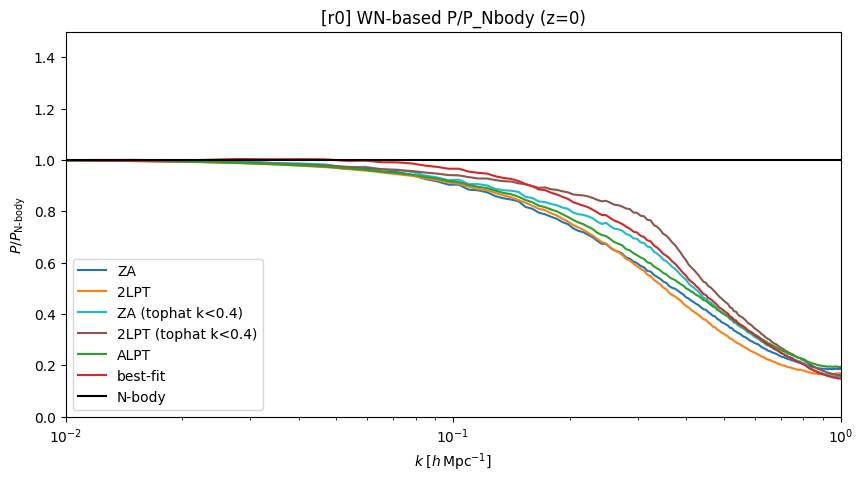

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import Pk_library as PKL
from pipeline import psi_div_to_delta, compute_best_fit

verify_r = 0  # seed for verification

# ── Load WN data (q_init + delta at z=0) ──────────────────────────────────
wn_info = dl.get_snapshot_wn(
    cfg.wn_psi1_path(verify_r, N_p),
    cfg.wn_qinit_path(verify_r, N_p),
    boxsize, grid_size)
q_init    = wn_info['q_init']
init_delta = wn_info['delta']

# ── Load final N-body snapshot ─────────────────────────────────────────────
final_path = cfg.final_snapshot_path(verify_r, N_p)
print(f'Loading final snapshot: {final_path}')
final_info = dl.get_snapshot(final_path, cfg.snapshot_format(N_p), boxsize, grid_size)
final_delta = final_info['delta']
final_pos   = final_info['pos']

# ── Compute target ∇·Ψ from N-body ────────────────────────────────────────
target_psi_div = dl.compute_target_psi_div_wn(q_init, final_pos, N_p, boxsize, veck_main)

# ── Best-fit analytical approximation ──────────────────────────────────────
bf_psi_div, bf_delta, tgt_delta = compute_best_fit(
    dl, init_delta, target_psi_div,
    q_init, final_delta,
    veck_main, N_p, boxsize, MAS,
    verify_r, data_dir, L,
    coef_file=None,
    overwrite=False,
)

# ── Approximate solutions for comparison ──────────────────────────────────
# Zel'dovich (ZA): 1st-order displacement
psi_div_ZA = dl.div_psi_1(init_delta)
delta_ZA   = psi_div_to_delta(psi_div_ZA, dl, q_init, veck_main, N_p, boxsize, MAS)

# 2LPT
psi_div_2  = dl.div_psi_2(init_delta, veck_main)
psi_div_2LPT = psi_div_ZA + psi_div_2
delta_2LPT = psi_div_to_delta(psi_div_2LPT, dl, q_init, veck_main, N_p, boxsize, MAS)

# Low-pass top-hat filter in k-space on ∇·Ψ, then reconstruct with the same pipeline
k_cut = 0.4
k_filter = dl.k_tophat_filter(0.0, k_cut, veck_main)

psi_div_ZA_th = dl.kx2x_convolve(k_filter, psi_div_ZA)
delta_ZA_th   = psi_div_to_delta(psi_div_ZA_th, dl, q_init, veck_main, N_p, boxsize, MAS)

psi_div_2LPT_th = dl.kx2x_convolve(k_filter, psi_div_2LPT)
delta_2LPT_th   = psi_div_to_delta(psi_div_2LPT_th, dl, q_init, veck_main, N_p, boxsize, MAS)

# ALPT (augmented LPT)
LPT2_disp = dl.disp_from_psi_div(psi_div_2LPT, veck_main, N_p)
psi_div_ALPT = dl.div_ALPT(LPT2_disp, veck_main, rs=6, delta1=init_delta)
delta_ALPT = psi_div_to_delta(psi_div_ALPT, dl, q_init, veck_main, N_p, boxsize, MAS)

# ── P/P_Nbody comparison ──────────────────────────────────────────────────
labels = ['ZA', '2LPT', 'ZA (tophat k<0.4)', '2LPT (tophat k<0.4)', 'ALPT', 'best-fit', 'N-body']
deltas = [delta_ZA, delta_2LPT, delta_ZA_th, delta_2LPT_th, delta_ALPT, bf_delta, tgt_delta]
colors = ['tab:blue', 'tab:orange', 'tab:cyan', 'tab:brown', 'tab:green', 'tab:red', 'k']

pks = [PKL.Pk(d, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False) for d in deltas]
k = pks[0].k3D

fig, ax = plt.subplots(figsize=(10, 5))
for pk_i, lab, col in zip(pks, labels, colors):
    ax.plot(k, pk_i.Pk[:, 0] / pks[-1].Pk[:, 0], label=lab, color=col)

ax.set_xscale('log')
ax.set_xlabel(r'$k\;[h\,\mathrm{Mpc}^{-1}]$')
ax.set_ylabel(r'$P / P_{\rm N\text{-}body}$')
ax.set_xlim(0.01, 1.0)
ax.set_ylim(0, 1.5)
ax.legend()
plt.title(f'[r{verify_r}] WN-based P/P_Nbody (z=0)')
plt.show()

## 1. Training: IC → Residual

In [8]:
import numpy as np
from model.new_gen_patches import extract_patches
import model.new_train_model as train_module
from new_pipeline import compute_best_fit, free_gpu_memory

importlib.reload(cfg)

patch_size = cfg.patch_size
padding    = cfg.padding
overlap    = cfg.overlap
rotate     = cfg.vec_rotate  # False for vector fields

# ── Section settings ──────────────────────────────────────────────
train_realizations = cfg.train_realizations   # e.g. list(range(16))
coef_file = None  # fit from scratch for WN-based pipeline
# ──────────────────────────────────────────────────────────────────

train_path = cfg.vec_training_data_path(
    train_realizations, patch_size, padding, overlap, rotate, N_p)

if os.path.exists(train_path):
    cached = np.load(train_path)
    input_patches  = cached['input_patches']
    target_patches = cached['target_patches']
    print(f'Combined training data already exists, loaded: {train_path}')
    print(f'{input_patches.shape[0]} patch pairs, shape {input_patches.shape[1:]}')
else:
    all_input_patches  = []
    all_target_patches = []

    for r in train_realizations:
        train_path_r = cfg.vec_training_data_path(
            r, patch_size, padding, overlap, rotate, N_p)
        if os.path.exists(train_path_r):
            cached = np.load(train_path_r)
            inp_r = cached['input_patches']
            tgt_r = cached['target_patches']
            print(f'  [r{r}] training file exists, loaded: {train_path_r}')
        else:
            # Load WN data
            wn_info_r = dl.get_snapshot_wn(
                cfg.wn_psi1_path(r, N_p),
                cfg.wn_qinit_path(r, N_p),
                boxsize, grid_size)
            q_init_r    = wn_info_r['q_init']
            init_delta_r = wn_info_r['delta']

            # Load final N-body snapshot
            final_info_r = dl.get_snapshot(
                cfg.final_snapshot_path(r, N_p),
                cfg.snapshot_format(N_p),
                boxsize, grid_size)

            # Compute target psi_div AND full displacement field
            tgt_psi_div_r, tgt_psi_r = dl.compute_target_psi_wn(
                q_init_r, final_info_r['pos'], N_p, boxsize, veck_main)

            # Compute best-fit (returns 4-tuple with vector psi)
            bf_psi_div_r, bf_psi_r, _, _ = compute_best_fit(
                dl, init_delta_r, tgt_psi_div_r,
                q_init_r, final_info_r['delta'],
                veck_main, N_p, boxsize, MAS,
                r, data_dir, L,
                coef_file=coef_file,
                overwrite=False,
            )

            # Residual is in vector displacement space
            residual_psi_r = tgt_psi_r - bf_psi_r
            print(f'  [r{r}] residual psi chi^2 = {np.mean(residual_psi_r**2):.6e}')

            # Extract 4D patches: input=best_fit_psi (N,N,N,3), target=residual_psi (N,N,N,3)
            inp_r = extract_patches(bf_psi_r,       patch_size, padding, overlap, rotate)
            tgt_r = extract_patches(residual_psi_r, patch_size, padding, overlap, rotate)

            os.makedirs(os.path.dirname(train_path_r), exist_ok=True)
            np.savez(
                train_path_r,
                input_patches=inp_r,
                target_patches=tgt_r,
                patch_size=patch_size,
                padding=padding,
                overlap=overlap,
                realization=r,
            )
            print(f'  [r{r}] saved: {train_path_r}')
            del wn_info_r, final_info_r, tgt_psi_div_r, tgt_psi_r, bf_psi_div_r, bf_psi_r, residual_psi_r

        all_input_patches.append(inp_r)
        all_target_patches.append(tgt_r)

    input_patches  = np.concatenate(all_input_patches,  axis=0)
    target_patches = np.concatenate(all_target_patches, axis=0)
    assert input_patches.shape == target_patches.shape
    print(f'{input_patches.shape[0]} patch pairs from '
          f'{len(train_realizations)} realization(s), shape {input_patches.shape[1:]}')

    np.savez(train_path,
             input_patches=input_patches, target_patches=target_patches,
             patch_size=patch_size, padding=padding, overlap=overlap)
    print(f'combined training data saved: {train_path}')

Combined training data already exists, loaded: /pscratch/sd/l/liuyh15/DDDF/data/new_psi_vec/training-data-VEC-N256PS20P2O00RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15.npz
35152 patch pairs, shape (24, 24, 24, 3)


In [9]:
free_gpu_memory()

importlib.reload(cfg)

# ── Section settings ──────────────────────────────────────────────
overwrite_train = False   # True -> force retrain
# ──────────────────────────────────────────────────────────────────

model_name = cfg.vec_gan_model_name(
    train_realizations, patch_size, padding, rotate, N_p)

train_module.train_gan(
    training_data_path=train_path,
    save_file_name=model_name,
    batch_size=cfg.vec_batch_size,
    epochs=cfg.epochs,          # 5 in new_config
    lr_g=cfg.gan_lr_g,
    lr_d=cfg.gan_lr_d,
    lambda_pixel=cfg.gan_lambda_pixel,
    n_disc_layers=cfg.gan_n_disc_layers,
    lambda_fm=cfg.gan_lambda_fm,
    lambda_gp=cfg.gan_lambda_gp,
    d_update_interval=cfg.gan_d_update_interval,
    use_spectral_norm=cfg.gan_use_spectral_norm,
    checkpoint_interval=cfg.checkpoint_interval,
    resume_checkpoint='auto',
    overwrite=overwrite_train,
)

GPU memory in use: 0.00 GB
Detected 3 channel(s), spatial shape (24, 24, 24)
Auto-selected number of pooling levels: 4 (min side=24)
Using device: cuda
Generator parameters: 2,513,379
Discriminator parameters: 285,345
n_channels=3, lambda_pixel=5.0, lambda_fm=20.0, n_disc_layers=3, d_update_interval=3, use_spectral_norm=False, sn_impl=native, batch_size=512
Resuming training from checkpoint: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e200.ckpt
Completed 200 epochs, continue training to epoch 250.
Starting epoch 201/250...


Epoch 201/250: 100%|█| 69/69 [00:28<00:00,  2.39batch/s


Epoch 201/250,  loss_G=13.460371,  loss_D=-0.460266,  lr_G=9.05e-05,  lr_D=4.53e-05,  epoch_time=28.9s,  avg_epoch_time=28.9s,  train_eta=2026-04-17 00:00:05
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e201.ckpt
Starting epoch 202/250...


Epoch 202/250: 100%|█| 69/69 [00:28<00:00,  2.44batch/s


Epoch 202/250,  loss_G=13.479554,  loss_D=-0.460173,  lr_G=6.58e-05,  lr_D=3.29e-05,  epoch_time=28.3s,  avg_epoch_time=28.6s,  train_eta=2026-04-16 23:59:53
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e202.ckpt
Starting epoch 203/250...


...

Epoch 248/250,  loss_G=13.648178,  loss_D=-0.470162,  lr_G=6.58e-05,  lr_D=3.29e-05,  epoch_time=28.0s,  avg_epoch_time=28.1s,  train_eta=2026-04-16 23:59:33
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e248.ckpt
Starting epoch 249/250...


Epoch 249/250: 100%|█| 69/69 [00:27<00:00,  2.47batch/s


Epoch 249/250,  loss_G=13.685712,  loss_D=-0.475924,  lr_G=9.05e-05,  lr_D=4.53e-05,  epoch_time=28.0s,  avg_epoch_time=28.1s,  train_eta=2026-04-16 23:59:33
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e249.ckpt
Starting epoch 250/250...


Epoch 250/250: 100%|█| 69/69 [00:28<00:00,  2.46batch/s

Epoch 250/250,  loss_G=13.782832,  loss_D=-0.483070,  lr_G=1.00e-04,  lr_D=5.00e-05,  epoch_time=28.0s,  avg_epoch_time=28.1s,  train_eta=2026-04-16 23:59:33
Checkpoint saved: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e250.ckpt
Total training time: 1411.7s
GAN training complete, generator saved to: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e250.pth


## 2. Verification

Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/psi1_grid_z127_seed000_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/0/wn/q_init_seed000_n256.npz
psi1 grid: 256^3,  dplus=101.025389,  box_file=1000000.0 (kpc/h)
delta(z=0): mean=1.164153e-10, std=1.918638
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading best-fit psi_div from /pscratch/sd/l/liuyh15/DDDF/data/new_tophat0.4/best-fitL1N256-0.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e250.pth (pools=4, device=cuda)


apply_model (z-slices): 100%|█| 13/13 [00:07<00:00,  1.


apply_model done: step=20, elapsed=7.5s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


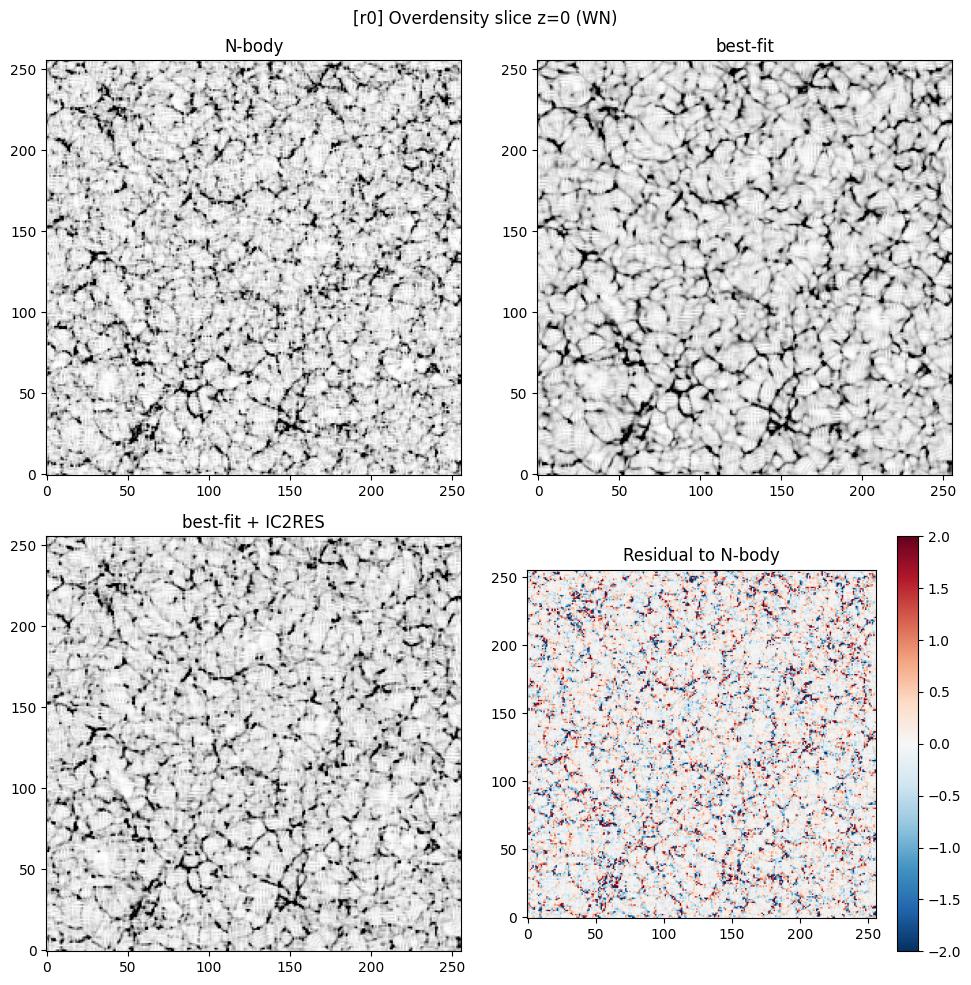

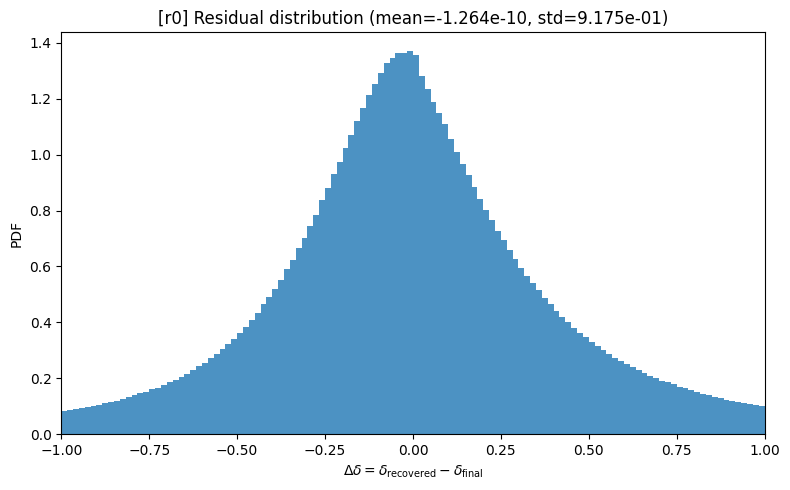

[r0] Nyquist target k = 0.804248, nearest-bin k = 0.807336


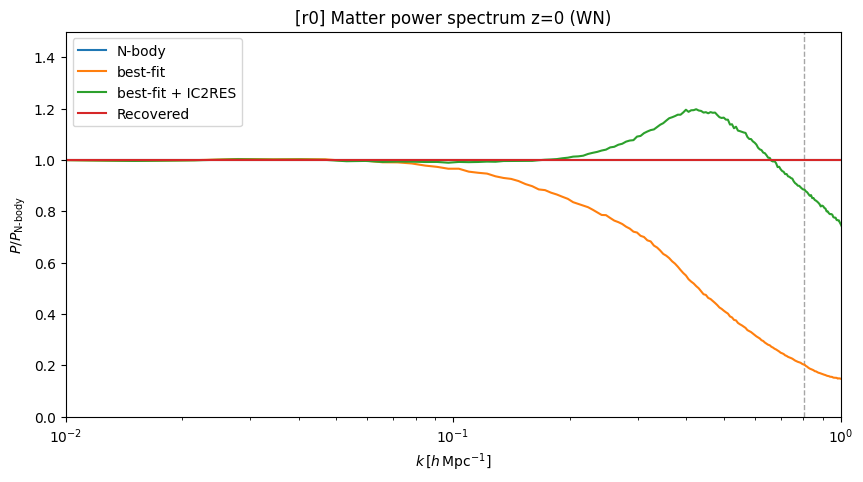

[r0] N-body P/P_N-body @Nyquist = 100.00%
[r0] best-fit P/P_N-body @Nyquist = 20.19%
[r0] best-fit + IC2RES P/P_N-body @Nyquist = 88.38%
[r0] Recovered P/P_N-body @Nyquist = 100.00%
[r0] best-fit chi^2 (k<=0.3) = 2.083079e-02
[r0] best-fit + IC2RES chi^2 (k<=0.3) = 9.353212e-04
[r0] Recovered chi^2 (k<=0.3) = 2.495233e-17
Loading psi1 from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/psi1_grid_z127_seed019_n256.npz
Loading q_init from /pscratch/sd/l/liuyh15/Quijote/fiducial_LR/19/wn/q_init_seed019_n256.npz
psi1 grid: 256^3,  dplus=101.025389,  box_file=1000000.0 (kpc/h)
delta(z=0): mean=0.000000e+00, std=1.918345
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Loading best-fit psi_div from /pscratch/sd/l/liuyh15/DDDF/data/new_tophat0.4/best-fitL1N256-19.npz
GAN Loaded: /pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e250.pth (pools=4, device=cuda)


apply_model (z-slices): 100%|█| 13/13 [00:07<00:00,  1.


apply_model done: step=20, elapsed=7.4s
Assigning displacements to particles using CIC...
Assigning displacements to particles using CIC...


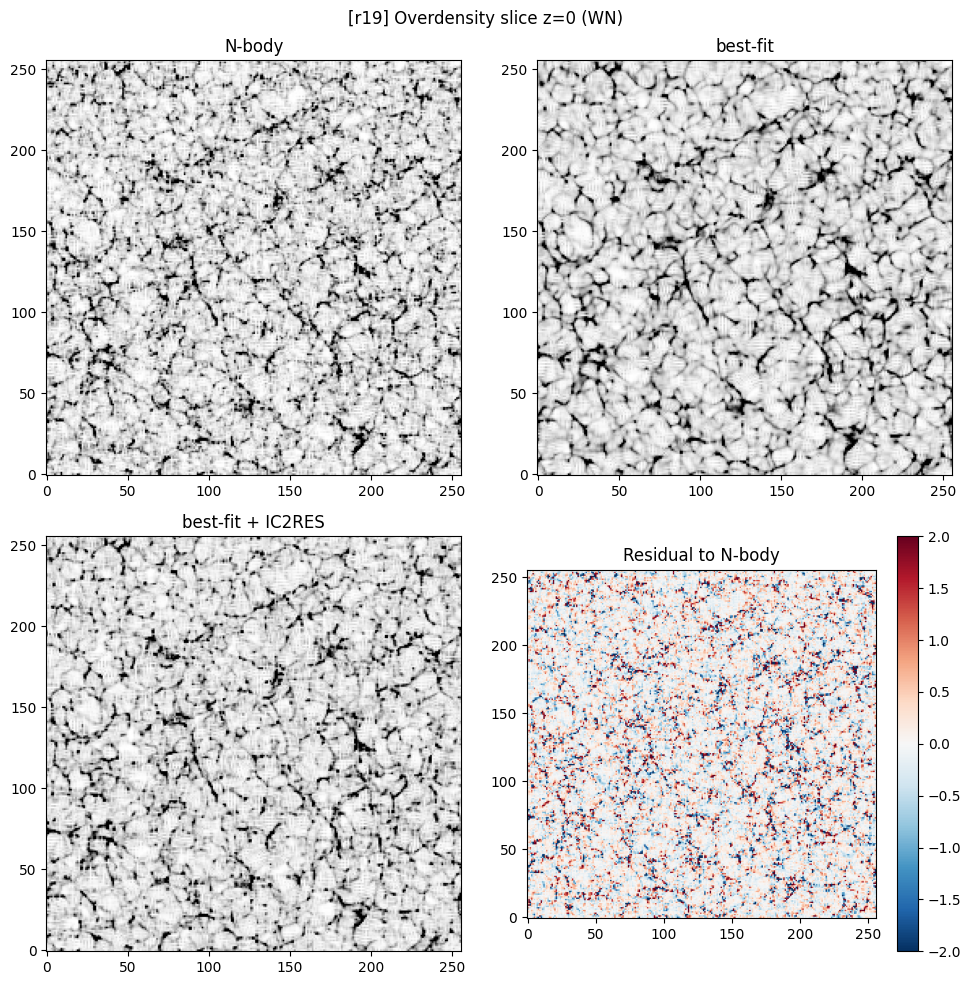

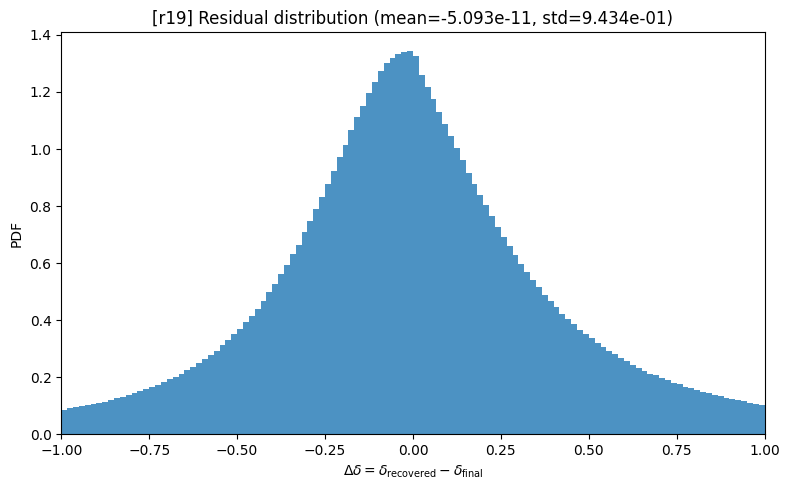

[r19] Nyquist target k = 0.804248, nearest-bin k = 0.807336


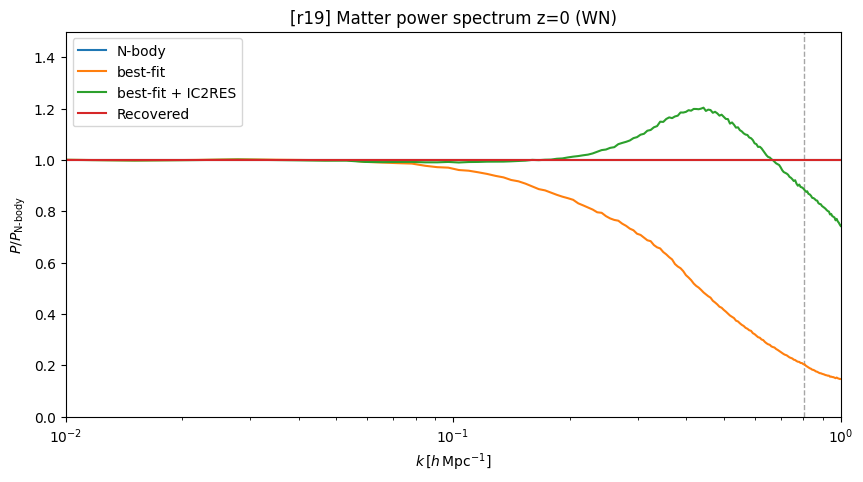

[r19] N-body P/P_N-body @Nyquist = 100.00%
[r19] best-fit P/P_N-body @Nyquist = 20.34%
[r19] best-fit + IC2RES P/P_N-body @Nyquist = 88.25%
[r19] Recovered P/P_N-body @Nyquist = 100.00%
[r19] best-fit chi^2 (k<=0.3) = 2.057808e-02
[r19] best-fit + IC2RES chi^2 (k<=0.3) = 9.645236e-04
[r19] Recovered chi^2 (k<=0.3) = 2.038255e-17


{'realization': 19,
 'checkpoint': '/pscratch/sd/l/liuyh15/DDDF/models/new_psi_vec_v1/gan-VEC-N256PS20P2RotateFalse-0+1+2+3+4+5+6+7+8+9+10+11+12+13+14+15-e250.pth',
 'chi2': {'best-fit': 0.020578076688901336,
  'best-fit + IC2RES': 0.0009645236312963504,
  'Recovered': 2.0382552968860823e-17},
 'labels': ['N-body', 'best-fit', 'best-fit + IC2RES', 'Recovered']}

In [10]:
importlib.reload(cfg)
import new_verify
importlib.reload(new_verify)
from new_verify import verify_realization

verify_realization(realization=0)
verify_realization(realization=19)